<a href="https://colab.research.google.com/github/jessicalewinter/deep-learning-specialization/blob/main/course-notebooks/machine-learning/ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bagging
### Bootstrapping Algorithm

In [2]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [3]:
# Load_iris
iris = load_iris()
X = iris.data
y= iris.target
RANDOM_STATE = 42
# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print(f"Data split. X_train shape {X_train.shape}, X_test shape {X_test.shape}")

Data split. X_train shape (105, 4), X_test shape (45, 4)


In [4]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, criterion='entropy')

## training model
random_forest_model.fit(X_train, y_train)

## Classifier results
print(random_forest_model)

print(classification_report(y_test, random_forest_model.predict(X_test)))

RandomForestClassifier(criterion='entropy', random_state=42)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.78      0.93      0.85        15
           2       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



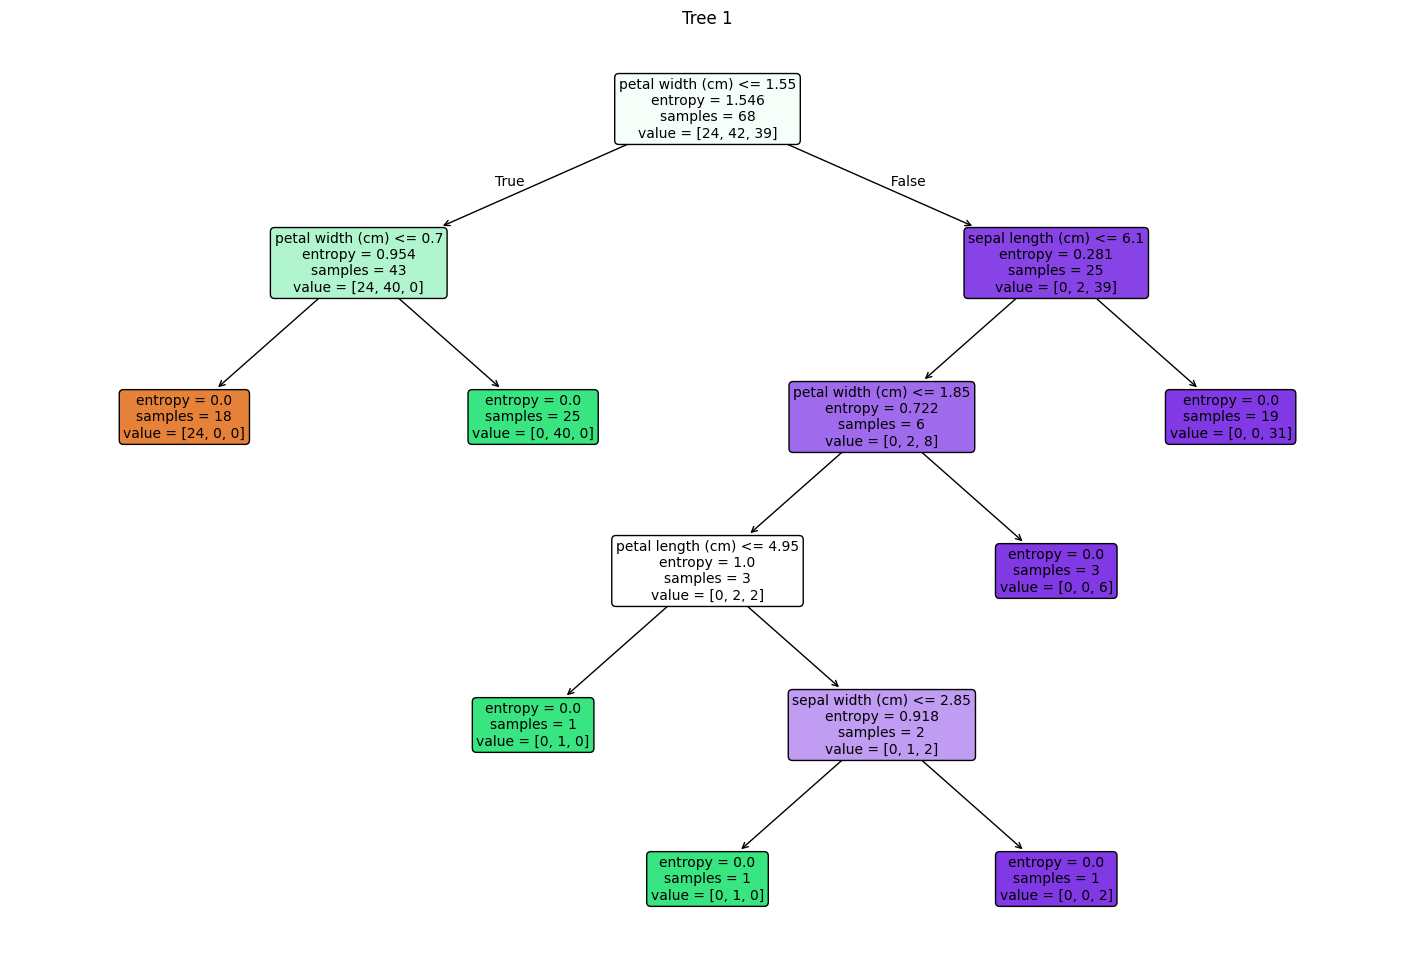

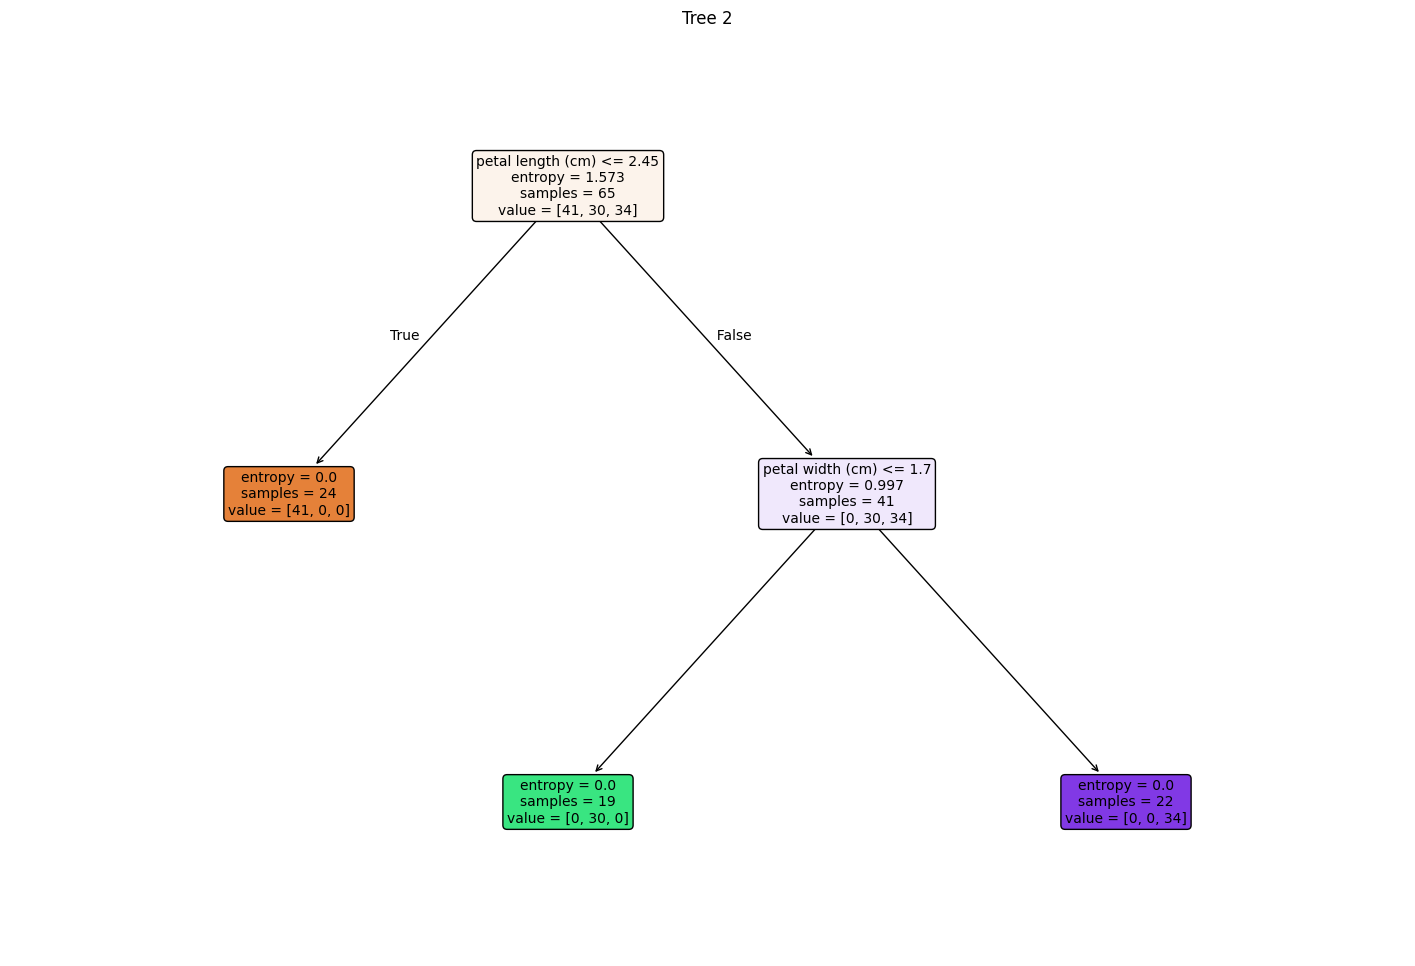

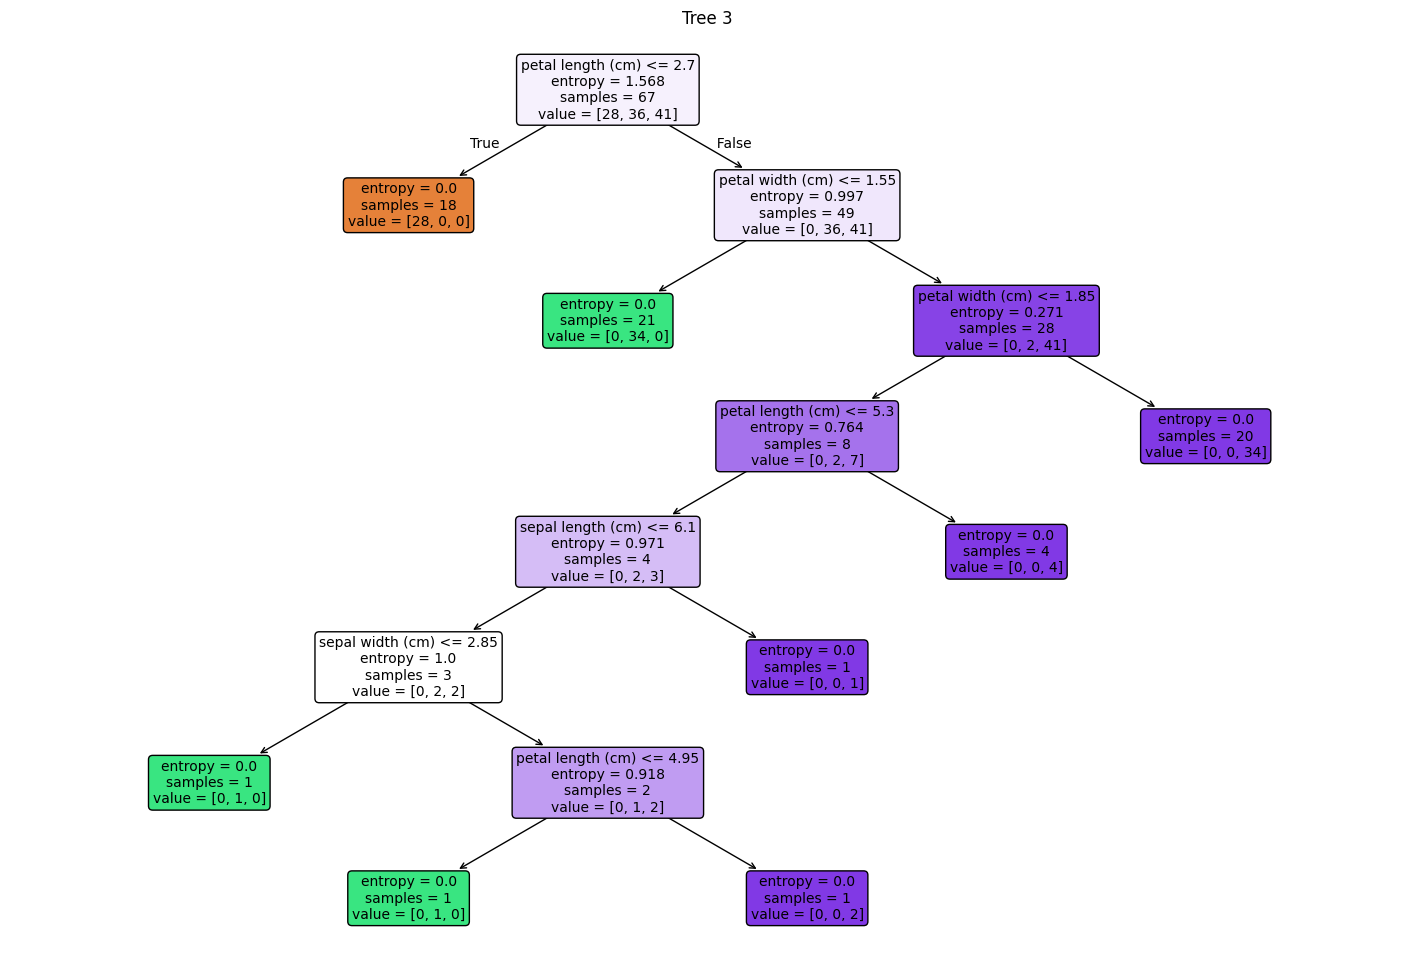

In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree # Import plot_tree

## Visualize the first 3 tree
for i in range(3):
    tree = random_forest_model.estimators_[i]

    plt.figure(figsize=(18, 12))
    plot_tree(tree, feature_names=iris.feature_names, filled=True, fontsize=10, rounded=True) # Corrected feature_names
    plt.title(f"Tree {i+1}")
    plt.show()

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=20)

parameters = {
    'n_estimators': [50, 100, 150],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=model,
                           param_grid=parameters,
                           scoring = 'f1_macro',
                           cv=5)
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print(f"Best paramter: {grid_search.best_params_}")

Best paramter: {'criterion': 'gini', 'n_estimators': 50}


In [7]:
print(model)

model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

RandomForestClassifier(random_state=20)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## Boosting Algorithm
### Adaboosting

In [8]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [9]:
adaboost_classifier_model = AdaBoostClassifier(estimator=None, random_state=20)

# Training the model
adaboost_classifier_model.fit(X_train, y_train)

# Saving the prediction
y_pred = model.predict(X_test)

print("Parameters\n")
print(adaboost_classifier_model.get_params())
# Deprecated since version 1.2: base_estimator is deprecated and will be removed in 1.4. Use estimator instead.

print("\nEstimator\n")
print(adaboost_classifier_model.estimator_)

Parameters

{'algorithm': 'deprecated', 'estimator': None, 'learning_rate': 1.0, 'n_estimators': 50, 'random_state': 20}

Estimator

DecisionTreeClassifier(max_depth=1)


In [ ]:
# Confusion Matrix with

In [10]:
model_dt = DecisionTreeClassifier(max_depth=1, random_state=20)

#treinando o modelo
model_dt = model_dt.fit(X_train, y_train)

#Salvando as predições
y_pred_dt = model_dt.predict(X_test)

## XGBoost

In [11]:
!pip install xgboost

In [12]:
import xgboost as xgb
from xgboost import XGBClassifier

model = XGBClassifier(random_state=20)

print(f"Paramters: {model.getParams()}")

AttributeError: 'XGBClassifier' object has no attribute 'getParams'